1. 설정 / 로드

In [1]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd


EMBEDDINGS_DIR = Path("embeddings")

GOLDEN_LABEL = "Qwen3-Embedding-0.6B-f16.gguf"
GOLDEN_PATH = EMBEDDINGS_DIR / f"{GOLDEN_LABEL}.json"

OUTPUT_DIR = Path("outputs_same_input_similarity")
OUTPUT_DIR.mkdir(exist_ok=True)

assert EMBEDDINGS_DIR.exists(), f"Directory not found: {EMBEDDINGS_DIR.resolve()}"
assert GOLDEN_PATH.exists(), f"Golden file not found: {GOLDEN_PATH.resolve()}"

json_paths = sorted(EMBEDDINGS_DIR.glob("*.json"))

print("Found files:")
for path in json_paths:
    print("-", path.name)

Found files:
- Qwen3-Embedding-0.6B-Q8_0.gguf.json
- Qwen3-Embedding-0.6B-f16.gguf.json
- Qwen3-Embedding-0.6B.i1-Q2_K.gguf.json
- Qwen3-Embedding-0.6B.i1-Q3_K_M.gguf.json
- Qwen3-Embedding-0.6B.i1-Q4_K_M.gguf.json
- Qwen3-Embedding-0.6B.i1-Q5_K_M.gguf.json
- Qwen3-Embedding-0.6B.i1-Q6_K.gguf.json


2. JSON flatten 함수

In [2]:
def load_embedding_json(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def flatten_embedding_file(path: Path) -> pd.DataFrame:
    data = load_embedding_json(path)

    # 파일명에서 label 추출: xxx.gguf.json -> xxx.gguf
    label = path.stem

    rows = []

    groups = data.get("groups")
    if not isinstance(groups, dict):
        raise ValueError(f"Invalid JSON format: groups not found in {path}")

    for group_name, group_data in groups.items():
        items = group_data.get("items")
        if not isinstance(items, list):
            raise ValueError(f"Invalid JSON format: groups.{group_name}.items not found in {path}")

        for item in items:
            embedding = item.get("embedding")

            if embedding is None:
                raise ValueError(f"Embedding missing: {path}, group={group_name}, item={item}")

            rows.append({
                "label": label,
                "group": group_name,
                "index": int(item["index"]),
                "text": item["text"],
                "dimension": len(embedding),
                "embedding": np.asarray(embedding, dtype=np.float32),
            })

    return pd.DataFrame(rows)


all_df = pd.concat(
    [flatten_embedding_file(path) for path in json_paths],
    ignore_index=True,
)

all_df.head()

,label,group,index,text,dimension,embedding
0,Qwen3-Embedding-0.6B-Q8_0.gguf,words,0,회사원,1024,"[-0.0030338056, -0.15160239, -0.011095128, -0...."
1,Qwen3-Embedding-0.6B-Q8_0.gguf,words,1,살해범,1024,"[-0.011650151, -0.01508228, -0.011664755, 0.04..."
2,Qwen3-Embedding-0.6B-Q8_0.gguf,words,2,수캐,1024,"[0.01099435, -0.019578675, -0.013508767, 0.023..."
3,Qwen3-Embedding-0.6B-Q8_0.gguf,words,3,퍼덕이다,1024,"[0.016206378, -0.011092099, -0.014384843, -0.0..."
4,Qwen3-Embedding-0.6B-Q8_0.gguf,words,4,마그마,1024,"[-0.010670422, -0.027787939, -0.012867507, -0...."


3. 기본 검증

In [3]:
print("Models:")
display(
    all_df.groupby("label")
    .agg(
        rows=("embedding", "count"),
        dimensions=("dimension", lambda x: sorted(set(x))),
        groups=("group", lambda x: sorted(set(x))),
    )
    .reset_index()
)

# 모든 모델이 golden과 같은 group/index/text 구성을 갖는지 확인
golden_df = all_df[all_df["label"] == GOLDEN_LABEL].copy()

assert not golden_df.empty, f"Golden label not found in loaded data: {GOLDEN_LABEL}"

golden_keys = set(zip(golden_df["group"], golden_df["index"], golden_df["text"]))

for label, model_df in all_df.groupby("label"):
    model_keys = set(zip(model_df["group"], model_df["index"], model_df["text"]))

    missing = golden_keys - model_keys
    extra = model_keys - golden_keys

    if missing or extra:
        print(f"[WARN] key mismatch: {label}")
        print("missing from model:", len(missing))
        print("extra in model:", len(extra))

    assert not missing, f"{label}: missing inputs compared to golden"
    assert not extra, f"{label}: extra inputs compared to golden"

print("검증 완료: 모든 모델의 입력 구성이 golden과 동일함")

Models:


,label,rows,dimensions,groups
0,Qwen3-Embedding-0.6B-Q8_0.gguf,2300,[1024],"[documents, sentences, words]"
1,Qwen3-Embedding-0.6B-f16.gguf,2300,[1024],"[documents, sentences, words]"
2,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,2300,[1024],"[documents, sentences, words]"
3,Qwen3-Embedding-0.6B.i1-Q3_K_M.gguf,2300,[1024],"[documents, sentences, words]"
4,Qwen3-Embedding-0.6B.i1-Q4_K_M.gguf,2300,[1024],"[documents, sentences, words]"
5,Qwen3-Embedding-0.6B.i1-Q5_K_M.gguf,2300,[1024],"[documents, sentences, words]"
6,Qwen3-Embedding-0.6B.i1-Q6_K.gguf,2300,[1024],"[documents, sentences, words]"


검증 완료: 모든 모델의 입력 구성이 golden과 동일함


4. Golden 대비 cosine similarity 계산

In [4]:
def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    a_norm = np.linalg.norm(a)
    b_norm = np.linalg.norm(b)

    if a_norm == 0 or b_norm == 0:
        return float("nan")

    return float(np.dot(a, b) / (a_norm * b_norm))


def l2_distance(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.linalg.norm(a - b))


def max_abs_diff(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.max(np.abs(a - b)))


# golden embedding을 lookup dict로 구성
golden_lookup = {
    (row.group, row.index): {
        "text": row.text,
        "embedding": row.embedding,
        "dimension": row.dimension,
    }
    for row in golden_df.itertuples(index=False)
}


comparison_rows = []

for row in all_df.itertuples(index=False):
    #if row.label == GOLDEN_LABEL:
    #    continue

    key = (row.group, row.index)
    golden = golden_lookup[key]

    if row.text != golden["text"]:
        raise ValueError(
            f"Text mismatch: label={row.label}, group={row.group}, index={row.index}"
        )

    if row.dimension != golden["dimension"]:
        raise ValueError(
            f"Dimension mismatch: label={row.label}, group={row.group}, index={row.index}, "
            f"golden_dim={golden['dimension']}, model_dim={row.dimension}"
        )

    cos = cosine_similarity(golden["embedding"], row.embedding)

    comparison_rows.append({
        "label": row.label,
        "group": row.group,
        "index": row.index,
        "text": row.text,
        "dimension": row.dimension,
        "cosine_similarity": cos,
        "cosine_distance": 1.0 - cos,
        "l2_distance": l2_distance(golden["embedding"], row.embedding),
        "max_abs_diff": max_abs_diff(golden["embedding"], row.embedding),
    })


cmp_df = pd.DataFrame(comparison_rows)

display(cmp_df.head())

,label,group,index,text,dimension,cosine_similarity,cosine_distance,l2_distance,max_abs_diff
0,Qwen3-Embedding-0.6B-Q8_0.gguf,words,0,회사원,1024,0.999053,0.000947,0.043530,0.004848
1,Qwen3-Embedding-0.6B-Q8_0.gguf,words,1,살해범,1024,0.999561,0.000439,0.029645,0.003035
2,Qwen3-Embedding-0.6B-Q8_0.gguf,words,2,수캐,1024,0.999465,0.000535,0.032710,0.003473
3,Qwen3-Embedding-0.6B-Q8_0.gguf,words,3,퍼덕이다,1024,0.999503,0.000497,0.031543,0.003973
4,Qwen3-Embedding-0.6B-Q8_0.gguf,words,4,마그마,1024,0.999685,0.000315,0.025086,0.004563


5. 모델별 요약

In [5]:
summary_by_model = (
    cmp_df
    .groupby("label")
    .agg(
        count=("cosine_similarity", "count"),

        cosine_mean=("cosine_similarity", "mean"),
        cosine_min=("cosine_similarity", "min"),
        cosine_p01=("cosine_similarity", lambda x: x.quantile(0.01)),
        cosine_p05=("cosine_similarity", lambda x: x.quantile(0.05)),
        cosine_p50=("cosine_similarity", "median"),

        cosine_distance_mean=("cosine_distance", "mean"),
        cosine_distance_max=("cosine_distance", "max"),

        l2_mean=("l2_distance", "mean"),
        l2_max=("l2_distance", "max"),

        max_abs_diff_mean=("max_abs_diff", "mean"),
        max_abs_diff_max=("max_abs_diff", "max"),
    )
    .sort_values("cosine_mean", ascending=False)
    .reset_index()
)

display(summary_by_model)

,label,count,cosine_mean,cosine_min,cosine_p01,cosine_p05,cosine_p50,cosine_distance_mean,cosine_distance_max,l2_mean,l2_max,max_abs_diff_mean,max_abs_diff_max
0,Qwen3-Embedding-0.6B-f16.gguf,2300,1.000000,1.000000,1.000000,1.000000,1.000000,-3.431154e-08,0.000000,0.000000,0.000000,0.000000,0.000000
1,Qwen3-Embedding-0.6B-Q8_0.gguf,2300,0.999051,0.987940,0.997324,0.998367,0.999128,9.493382e-04,0.012060,0.042434,0.155306,0.005698,0.018838
2,Qwen3-Embedding-0.6B.i1-Q6_K.gguf,2300,0.995644,0.956822,0.987162,0.992132,0.996091,4.356050e-03,0.043178,0.091040,0.293864,0.011740,0.040901
3,Qwen3-Embedding-0.6B.i1-Q5_K_M.gguf,2300,0.989775,0.939935,0.970615,0.981330,0.990778,1.022541e-02,0.060065,0.139837,0.346597,0.017211,0.081065
4,Qwen3-Embedding-0.6B.i1-Q4_K_M.gguf,2300,0.971261,0.824067,0.919604,0.949561,0.973550,2.873851e-02,0.175933,0.235044,0.593183,0.028391,0.090086
5,Qwen3-Embedding-0.6B.i1-Q3_K_M.gguf,2300,0.920344,0.733604,0.824237,0.868586,0.924298,7.965604e-02,0.266396,0.392926,0.729926,0.046802,0.110319
6,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,2300,0.749853,0.447169,0.531352,0.604580,0.754003,2.501472e-01,0.552831,0.697983,1.051505,0.087341,0.153293


6. 모델 + 입력 타입별 요약

In [6]:
summary_by_model_group = (
    cmp_df
    .groupby(["label", "group"])
    .agg(
        count=("cosine_similarity", "count"),

        cosine_mean=("cosine_similarity", "mean"),
        cosine_min=("cosine_similarity", "min"),
        cosine_p05=("cosine_similarity", lambda x: x.quantile(0.05)),
        cosine_p50=("cosine_similarity", "median"),

        cosine_distance_mean=("cosine_distance", "mean"),
        cosine_distance_max=("cosine_distance", "max"),

        l2_mean=("l2_distance", "mean"),
        l2_max=("l2_distance", "max"),

        max_abs_diff_mean=("max_abs_diff", "mean"),
        max_abs_diff_max=("max_abs_diff", "max"),
    )
    .sort_values(["label", "group"])
    .reset_index()
)

display(summary_by_model_group)

,label,group,count,cosine_mean,cosine_min,cosine_p05,cosine_p50,cosine_distance_mean,cosine_distance_max,l2_mean,l2_max,max_abs_diff_mean,max_abs_diff_max
0,Qwen3-Embedding-0.6B-Q8_0.gguf,documents,300,0.999198,0.998575,0.998916,0.999216,8.018110e-04,0.001425,0.039870,0.053378,0.005559,0.011174
1,Qwen3-Embedding-0.6B-Q8_0.gguf,sentences,1000,0.998938,0.995057,0.998357,0.999007,1.061992e-03,0.004943,0.045629,0.099426,0.006319,0.012554
2,Qwen3-Embedding-0.6B-Q8_0.gguf,words,1000,0.999119,0.987940,0.998239,0.999290,8.809422e-04,0.012060,0.040008,0.155306,0.005120,0.018838
3,Qwen3-Embedding-0.6B-f16.gguf,documents,300,1.000000,1.000000,1.000000,1.000000,-3.496806e-08,0.000000,0.000000,0.000000,0.000000,0.000000
4,Qwen3-Embedding-0.6B-f16.gguf,sentences,1000,1.000000,1.000000,1.000000,1.000000,-3.528595e-08,0.000000,0.000000,0.000000,0.000000,0.000000
5,Qwen3-Embedding-0.6B-f16.gguf,words,1000,1.000000,1.000000,1.000000,1.000000,-3.314018e-08,0.000000,0.000000,0.000000,0.000000,0.000000
6,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,documents,300,0.756222,0.617690,0.692223,0.755127,2.437782e-01,0.382310,0.696032,0.874426,0.094245,0.153293
7,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,1000,0.691826,0.447169,0.560915,0.699283,3.081738e-01,0.552831,0.780464,1.051505,0.093796,0.145931
8,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,words,1000,0.805969,0.548464,0.694834,0.813920,1.940313e-01,0.451536,0.616087,0.950301,0.078815,0.151147
9,Qwen3-Embedding-0.6B.i1-Q3_K_M.gguf,documents,300,0.923046,0.868766,0.896749,0.924600,7.695401e-02,0.131234,0.390335,0.512317,0.043746,0.063898


7. Golden과 가장 많이 달라진 입력 확인

In [7]:
worst_rows = (
    cmp_df
    .sort_values("cosine_similarity", ascending=True)
    .loc[:, [
        "label",
        "group",
        "index",
        "cosine_similarity",
        "cosine_distance",
        "l2_distance",
        "max_abs_diff",
        "text",
    ]]
)

display(worst_rows.head(30))

,label,group,index,cosine_similarity,cosine_distance,l2_distance,max_abs_diff,text
5750,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,150,0.447169,0.552831,1.051505,0.125273,"다만 숙소는 꽤 좁은편이나, 혼자 또는 여자두명이 쓰기에 큰 불편함은 없을것같습니다."
6437,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,837,0.451863,0.548137,1.047031,0.103340,겨울철에 난방 적정 온도가 몇이야?
6556,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,956,0.453028,0.546972,1.045918,0.134776,방은 작지만 혼자 쓰기에 좋아요.
6550,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,950,0.476979,0.523021,1.022762,0.133074,황사가 올지 비가 올지 알고싶습니다.
5853,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,253,0.483948,0.516052,1.015925,0.104268,가정집에서 난방은 어떻게 효율적으로 해?
6347,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,747,0.484722,0.515278,1.015164,0.110910,하수구에 음식 버리지 말라고 했잖아.
5880,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,280,0.487735,0.512265,1.012191,0.117624,정말 너무너무너무 완벽했던 숙소였습니다
5868,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,268,0.493778,0.506222,1.006203,0.119703,어두운 방안 밝기 조정은 뭘해야 할 수 있는거야?
5754,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,154,0.499723,0.500277,1.000277,0.120117,집안 실내 습도 말고 온도는 어떻게 조정하나요?
6076,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,476,0.508337,0.491663,0.991628,0.116054,집안 어른들께 혼나기 싫으면 제사 시간 늦지 마.


8. 간단한 시각화

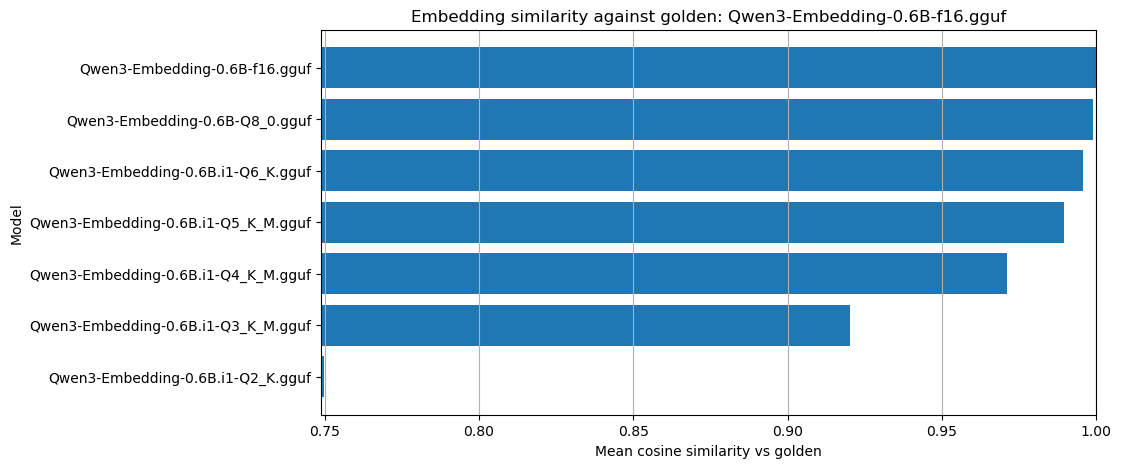

In [8]:
import matplotlib.pyplot as plt


plot_df = summary_by_model.sort_values("cosine_mean", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(plot_df["label"], plot_df["cosine_mean"])
plt.xlabel("Mean cosine similarity vs golden")
plt.ylabel("Model")
plt.title(f"Embedding similarity against golden: {GOLDEN_LABEL}")
plt.xlim(max(0.0, plot_df["cosine_mean"].min() - 0.001), 1.0001)
plt.grid(axis="x")
plt.show()

9. 결과 CSV 저장

In [9]:
# cmp_df.to_csv("embedding_similarity_detail.csv", index=False, encoding="utf-8-sig")
# summary_by_model.to_csv("embedding_similarity_summary_by_model.csv", index=False, encoding="utf-8-sig")
# summary_by_model_group.to_csv("embedding_similarity_summary_by_model_group.csv", index=False, encoding="utf-8-sig")

# print("saved:")
# print("- embedding_similarity_detail.csv")
# print("- embedding_similarity_summary_by_model.csv")
# print("- embedding_similarity_summary_by_model_group.csv")

saved: outputs_same_input_similarity/same_input_words_cosine_similarity.png


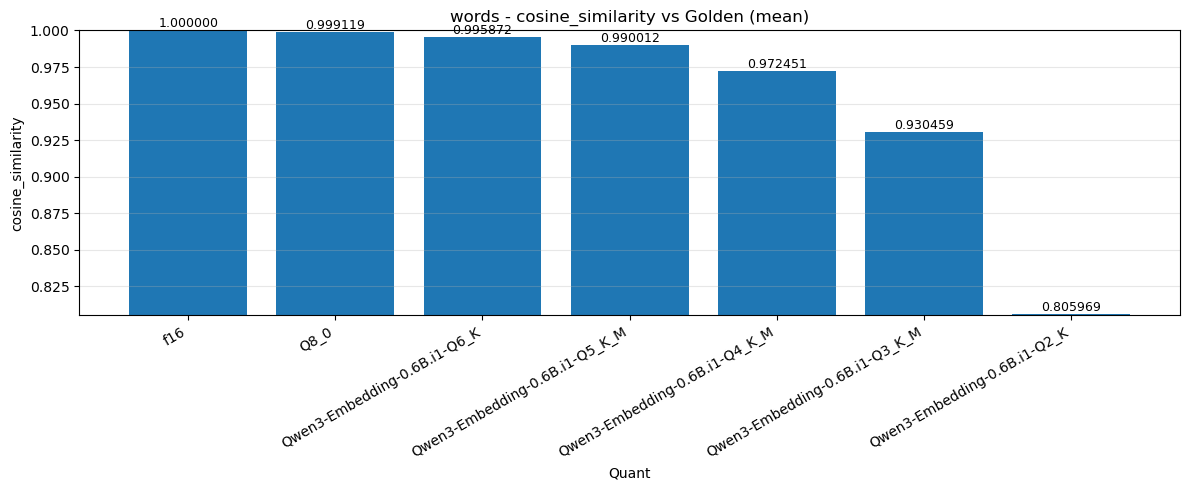

saved: outputs_same_input_similarity/same_input_sentences_cosine_similarity.png


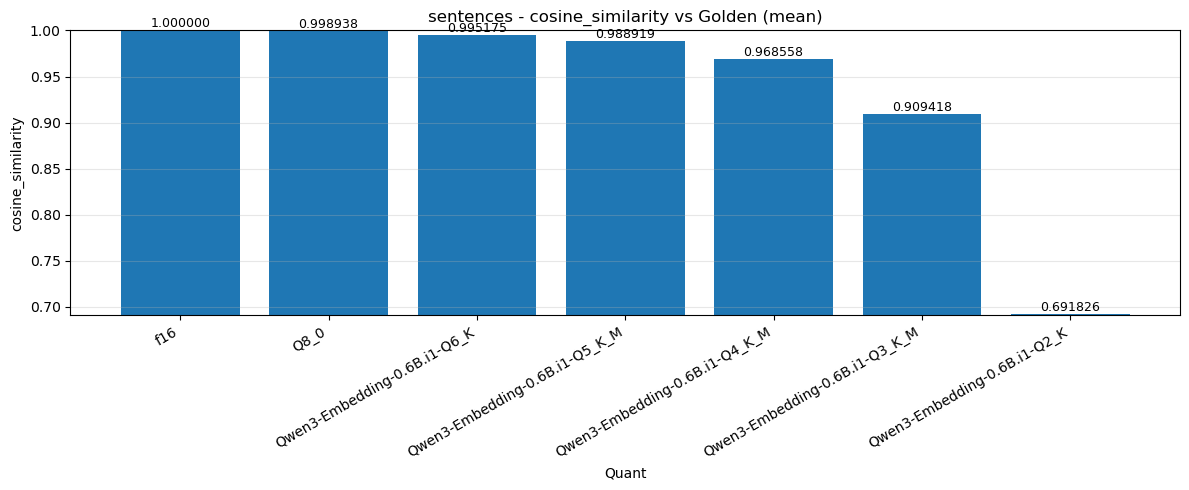

saved: outputs_same_input_similarity/same_input_documents_cosine_similarity.png


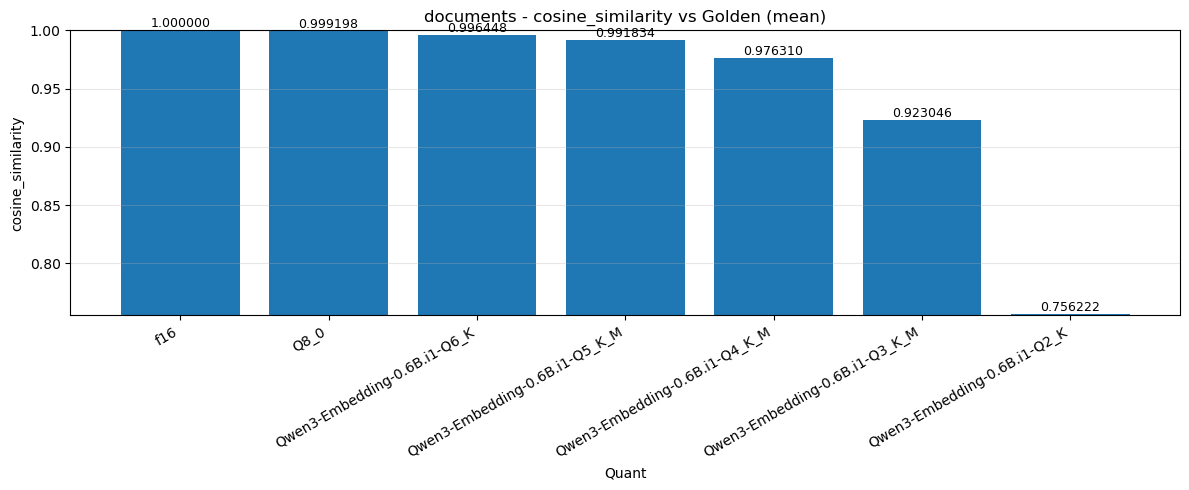

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


SIMILARITY_METRIC = "cosine_similarity"
AGG_FUNC = "mean"

GROUP_ORDER = ["words", "sentences", "documents"]


def short_model_label(label: str) -> str:
    """
    그래프 x축에 너무 긴 모델명을 그대로 넣으면 보기 힘드니까 짧게 정리.
    예:
      Qwen3-Embedding-0.6B-Q8_0.gguf -> Q8_0
      Qwen3-Embedding-0.6B-i1-Q4_K_M.gguf -> i1-Q4_K_M
    """
    prefix = "Qwen3-Embedding-0.6B-"
    suffix = ".gguf"

    name = label

    if name.startswith(prefix):
        name = name[len(prefix):]

    if name.endswith(suffix):
        name = name[:-len(suffix)]

    return name


def plot_similarity_bar_by_group(
    cmp_df: pd.DataFrame,
    group_name: str,
    metric: str = "cosine_similarity",
    agg_func: str = "mean",
    save: bool = True,
):
    group_df = cmp_df[cmp_df["group"] == group_name].copy()

    if group_df.empty:
        print(f"[SKIP] group not found or empty: {group_name}")
        return None

    plot_df = (
        group_df
        .groupby("label", as_index=False)
        .agg(
            similarity=(metric, agg_func),
            min_similarity=(metric, "min"),
            max_similarity=(metric, "max"),
            count=(metric, "count"),
        )
        .sort_values("similarity", ascending=False)
        .reset_index(drop=True)
    )

    plot_df["display_label"] = plot_df["label"].map(short_model_label)

    fig = plt.figure(figsize=(12, 5))
    ax = plt.gca()

    bars = ax.bar(
        plot_df["display_label"],
        plot_df["similarity"],
    )

    ax.set_title(f"{group_name} - {metric} vs Golden ({agg_func})")
    ax.set_xlabel("Quant")
    ax.set_ylabel(metric)

    if metric == "cosine_similarity":
        y_min = max(0.0, float(plot_df["similarity"].min()) - 0.001)
        y_max = min(1.0001, float(plot_df["similarity"].max()) + 0.0002)
        ax.set_ylim(y_min, y_max)

    ax.grid(axis="y", alpha=0.3)

    plt.xticks(rotation=30, ha="right")

    for bar, value in zip(bars, plot_df["similarity"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.6f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    plt.tight_layout()

    if save:
        output_path = OUTPUT_DIR / f"same_input_{group_name}_{metric}.png"
        plt.savefig(output_path, dpi=150, bbox_inches="tight")
        print(f"saved: {output_path}")

    plt.show()

    return plot_df


plot_tables = {}

for group_name in GROUP_ORDER:
    plot_tables[group_name] = plot_similarity_bar_by_group(
        cmp_df=cmp_df,
        group_name=group_name,
        metric="cosine_similarity",
        agg_func="mean",
        save=True,
    )